<a href="https://colab.research.google.com/github/PrashantBagri/IP_IIIT_Delhi_2026/blob/main/FMNIST_4_discretize_all.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


In [3]:

x_train = x_train / 255.0
x_test = x_test / 255.0


x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

print(x_train.shape)

(60000, 784)


In [4]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)


model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    x_train, y_train,
    epochs=60,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7775 - loss: 0.6385 - val_accuracy: 0.8355 - val_loss: 0.4603
Epoch 2/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8546 - loss: 0.4106 - val_accuracy: 0.8597 - val_loss: 0.4069
Epoch 3/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8682 - loss: 0.3663 - val_accuracy: 0.8712 - val_loss: 0.3658
Epoch 4/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8777 - loss: 0.3370 - val_accuracy: 0.8728 - val_loss: 0.3538
Epoch 5/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8836 - loss: 0.3188 - val_accuracy: 0.8762 - val_loss: 0.3400
Epoch 6/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8894 - loss: 0.3032 - val_accuracy: 0.8832 - val_loss: 0.3451
Epoch 7/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8950 - loss: 0.2870 - val_accuracy: 0.8805 - val_loss: 0.3367
Epoch 8/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8961 - loss: 0.2796 - val_accuracy: 

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8897 - loss: 0.5556
Test accuracy: 0.8896999955177307


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 334,544 (1.28 MB)

 Trainable params: 111,514 (435.60 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 223,030 (871.21 KB)

In [9]:

import matplotlib.pyplot as plt

dense_layers = []

for layer in model.layers:

    if isinstance(layer, keras.layers.Dense):
        dense_layers.append(layer)


# w0 = dense_layers[0].get_weights()[0]
# w1 = dense_layers[1].get_weights()[0]
# w2 = dense_layers[2].get_weights()[0]
w3 = dense_layers[3].get_weights()[0]

# b0 = dense_layers[0].get_weights()[1]
# b1 = dense_layers[1].get_weights()[1]
# b2 = dense_layers[2].get_weights()[1]
b3 = dense_layers[3].get_weights()[1]

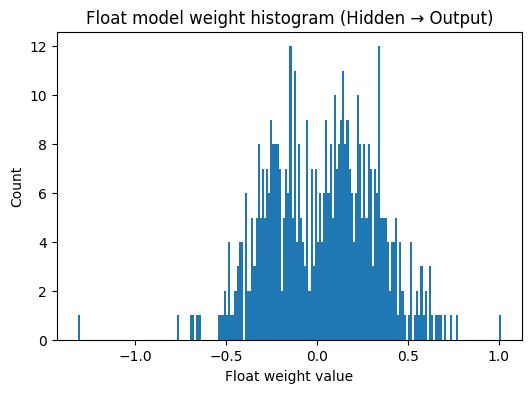

In [10]:
# w0_plot = dense_layers[0].get_weights()[0].reshape(-1)
# plt.figure(figsize=(6, 4))
# plt.hist(w0_plot, bins=200)
# plt.xlabel("Float weight value")
# plt.ylabel("Count")
# plt.title("Float model weight histogram (Input → Hidden)")
# # plt.xlim([-4, 4])
# plt.show()

# w1_plot = dense_layers[1].get_weights()[0].reshape(-1)

# plt.figure(figsize=(6, 4))
# plt.hist(w1_plot, bins=200)
# plt.xlabel("Float weight value")
# plt.ylabel("Count")
# plt.title("Float model weight histogram (Hidden → Output)")
# # plt.xlim([-4, 4])
# plt.show()

# w2_plot = dense_layers[2].get_weights()[0].reshape(-1)

# plt.figure(figsize=(6, 4))
# plt.hist(w2_plot, bins=200)
# plt.xlabel("Float weight value")
# plt.ylabel("Count")
# plt.title("Float model weight histogram (Hidden → Output)")
# # plt.xlim([-4, 4])
# plt.show()

w3_plot = dense_layers[3].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w3_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → Output)")
# plt.xlim([-4, 4])
plt.show()


In [11]:
# print(f"\n\n{w0}\n\n{w1}\n\n{w2}\n\n{w3}\n\n")

# w2.ndim
# w1
# w2
# w3

In [12]:

# levels1 = [-1.0 , -0.75, -0.25, 0.0 , 0.25, 0.75, 1.0]
levels = [-1.0 , -0.75, -0.25, 0.0 , 0.25, 0.75, 1.0]


def snap_weights_to_levels(weights, levels):


    levels = np.array(levels)
    snapped = np.zeros_like(weights)

    for i in range(weights.shape[0]):
        for j in range(weights.shape[1]):
            w = weights[i, j]


            if w <= levels[0]:
                snapped[i, j] = levels[0]
                continue
            if w >= levels[-1]:
                snapped[i, j] = levels[-1]
                continue


            for k in range(len(levels) - 1):
                low = levels[k]
                high = levels[k + 1]

                if low <= w <= high:
                    midpoint = (low + high) / 2

                    if w > midpoint:
                        snapped[i, j] = high
                    else:
                        snapped[i, j] = low
                    break

    return snapped


In [14]:
# snapped_w0 = snap_weights_to_levels(w0, levels)
# snapped_w1 = snap_weights_to_levels(w1, levels)
# snapped_w2 = snap_weights_to_levels(w2, levels)
snapped_w3 = snap_weights_to_levels(w3, levels)


# snapped_w0
# snapped_w1
# snapped_w2
# snapped_w3



In [15]:


# dense_layers[0].set_weights([snapped_w0, b0])
# dense_layers[1].set_weights([snapped_w1, b1])
# dense_layers[2].set_weights([snapped_w2, b2])
dense_layers[3].set_weights([snapped_w3, b3])



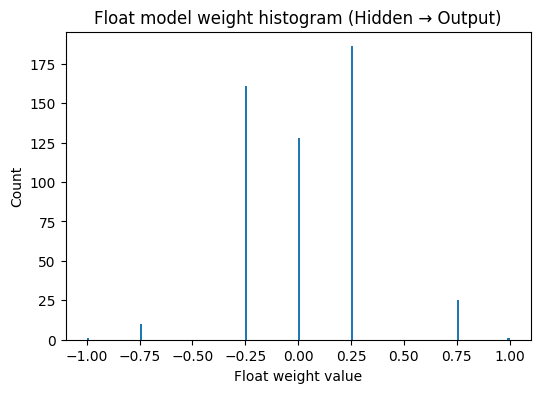

In [16]:
# w0_plot = dense_layers[0].get_weights()[0].reshape(-1)
# plt.figure(figsize=(6, 4))
# plt.hist(w0_plot, bins=200)
# plt.xlabel("Float weight value")
# plt.ylabel("Count")
# plt.title("Float model weight histogram (Input → Hidden)")
# # plt.xlim([-4, 4])
# plt.show()

# w1_plot = dense_layers[1].get_weights()[0].reshape(-1)

# plt.figure(figsize=(6, 4))
# plt.hist(w1_plot, bins=200)
# plt.xlabel("Float weight value")
# plt.ylabel("Count")
# plt.title("Float model weight histogram (Hidden → Output)")
# # plt.xlim([-4, 4])
# plt.show()

# w2_plot = dense_layers[2].get_weights()[0].reshape(-1)

# plt.figure(figsize=(6, 4))
# plt.hist(w2_plot, bins=200)
# plt.xlabel("Float weight value")
# plt.ylabel("Count")
# plt.title("Float model weight histogram (Hidden → Output)")
# # plt.xlim([-4, 4])
# plt.show()

w3_plot = dense_layers[3].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w3_plot, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → Output)")
# plt.xlim([-4, 4])
plt.show()


In [17]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8687 - loss: 0.6177
Test accuracy: 0.8687000274658203


In [18]:
history = model.fit(
    x_train, y_train,
    epochs=60,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9676 - loss: 0.0878 - val_accuracy: 0.8855 - val_loss: 0.5137
Epoch 2/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9701 - loss: 0.0794 - val_accuracy: 0.8888 - val_loss: 0.5129
Epoch 3/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9711 - loss: 0.0764 - val_accuracy: 0.8807 - val_loss: 0.5730
Epoch 4/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9708 - loss: 0.0764 - val_accuracy: 0.8863 - val_loss: 0.5768
Epoch 5/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9712 - loss: 0.0771 - val_accuracy: 0.8833 - val_loss: 0.6762
Epoch 6/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9700 - loss: 0.0785 - val_accuracy: 0.8920 - val_loss: 0.5311
Epoch 7/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9714 - loss: 0.0740 - val_accuracy: 0.8895 - val_loss: 0.5268
Epoch 8/60
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9723 - loss: 0.0736 - val_accuracy: 0

In [19]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8783 - loss: 0.8784
Test accuracy: 0.8783000111579895


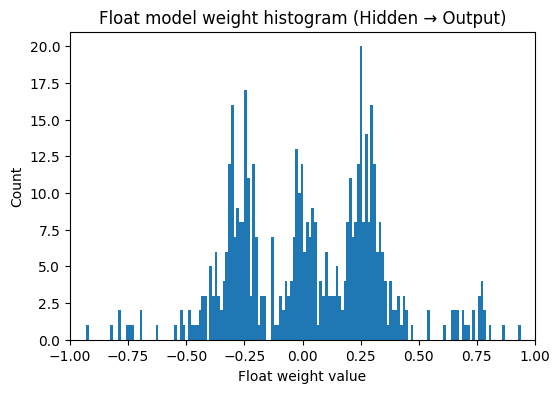

In [21]:
# w2 = dense_layers[0].get_weights()[0].reshape(-1)
# plt.figure(figsize=(6, 4))
# plt.hist(w2, bins=200)
# plt.xlabel("Float weight value")
# plt.ylabel("Count")
# plt.title("Float model weight histogram (Input → Hidden)")
# plt.xlim([-1, 1])
# plt.show()

# w2 = dense_layers[1].get_weights()[0].reshape(-1)

# plt.figure(figsize=(6, 4))
# plt.hist(w2, bins=200)
# plt.xlabel("Float weight value")
# plt.ylabel("Count")
# plt.title("Float model weight histogram (Hidden → Output)")
# plt.xlim([-1, 1])
# plt.show()

# w2 = dense_layers[2].get_weights()[0].reshape(-1)

# plt.figure(figsize=(6, 4))
# plt.hist(w2, bins=200)
# plt.xlabel("Float weight value")
# plt.ylabel("Count")
# plt.title("Float model weight histogram (Hidden → Output)")
# plt.xlim([-1, 1])
# plt.show()
w2 = dense_layers[3].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w2, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Hidden → Output)")
plt.xlim([-1,1])
plt.show()
